# Convolutional Neural Networks — From Scratch to Transfer Learning

**Author:** Shivani Bokka  
**Dataset:** CIFAR-10 (10-class image classification)  
**Goal:** Understand CNNs by building one from scratch, then leverage transfer learning

---

## What Is This Notebook About?

This notebook is a **complete walkthrough of Convolutional Neural Networks (CNNs)** — from the very first principles of how convolution works, all the way to state-of-the-art transfer learning. Every section explains the core idea in plain language before diving into the code.

Whether you are a student seeing CNNs for the first time, or a practitioner looking for a clean reference on transfer learning and explainability, this notebook covers it all in one place.

---

## What Is a Convolutional Neural Network?

A regular (fully connected) neural network treats an image as a flat list of pixel values and processes every pixel with every neuron. That works for tiny images, but it explodes in cost as images get larger — and it throws away all spatial information.

A **CNN** instead:
1. Slides small **filters** (kernels) across the image, detecting local patterns like edges, corners, and textures.
2. Stacks these detectors in **layers** so that each deeper layer sees combinations of the patterns found below it.
3. Keeps **spatial structure** intact through most of the network, only flattening at the very end.

The result is a model that is enormously more efficient than a fully connected network for image data — and far better at recognising that a cat is a cat no matter where in the photo it appears.

---

## What Is CIFAR-10?

CIFAR-10 is a benchmark dataset of **60,000 colour images** (32×32 pixels), split into **10 classes**:

| Class | Examples |
|-------|----------|
| airplane | jet, propeller plane |
| automobile | car, truck |
| bird | parrot, eagle |
| cat | domestic cat |
| deer | elk, deer |
| dog | domestic dog |
| frog | tree frog, toad |
| horse | horse, pony |
| ship | sailboat, cargo ship |
| truck | pickup, lorry |

50,000 images are used for training, 10,000 for testing. It is small enough to train quickly but hard enough that you need a real model to do well.

---

## Sections in This Notebook

| # | Section | Key Ideas |
|---|---------|----------|
| 1 | Imports and Setup | PyTorch, torchvision, seeds, device |
| 2 | How Convolution Works | Filters, feature maps, edge detection, receptive field |
| 3 | Data Loading and Augmentation | CIFAR-10, transforms, augmentation effects |
| 4 | CNN From Scratch | Architecture, training, learning curves |
| 5 | Feature Map Visualization | What each layer sees |
| 6 | Grad-CAM | Where the model is looking |
| 7 | Transfer Learning with ResNet-18 | Frozen vs full fine-tuning |
| 8 | Scratch vs Transfer Learning | Convergence comparison |
| 9 | When to Freeze vs Fine-Tune | Decision guide |
| 10 | Grad-CAM on ResNet-18 | Comparing attention maps |
| 11 | Summary and Key Takeaways | What to remember |

---

---

## Section 1 — Imports and Setup

We import everything we need up front so nothing is hidden later in the notebook.

- **torch / torch.nn / torch.nn.functional** — the core PyTorch library for tensors, layers, and operations
- **torchvision** — datasets (CIFAR-10), transforms, and pre-trained model zoo
- **matplotlib** — plotting
- **numpy** — numerical utilities

We also set random seeds so every run produces the same results, and we detect whether a GPU (CUDA) is available. CNNs can be trained on CPU, but GPU training is 10–50× faster.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms.v2 as transforms_v2
import torchvision.models as models
from torchvision.datasets import CIFAR10

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import warnings
import random
import os

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# CIFAR-10 class names
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

print('All imports successful.')

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
All imports successful.


---

## Section 2 — How Convolution Works

### The Big Idea

A **convolution** slides a small filter (kernel) across an image, computing a dot product at each position. The result is a **feature map** that highlights wherever the pattern in the filter is found in the input.

Think of it like a stamp: you press the stamp at every position in the image and record how strongly the image pattern there matches the stamp's pattern. If the stamp contains a horizontal edge pattern, the resulting feature map will light up wherever horizontal edges exist in the image.

### Key Parameters

| Parameter | What It Does |
|-----------|-------------|
| **kernel_size** | How big the filter is (e.g., 3×3 or 5×5) |
| **stride** | How many pixels to skip between positions |
| **padding** | How many zero pixels to add around the border |
| **out_channels** | How many different filters to use |

### The Sobel Filter — A Classic Edge Detector

Before neural networks learn their own filters, people hand-crafted filters for specific purposes. The **Sobel filter** is a famous example:

- **Horizontal Sobel** detects horizontal edges (changes in the vertical direction)
- **Vertical Sobel** detects vertical edges (changes in the horizontal direction)

In the code below we apply these by hand to a CIFAR-10 image using `F.conv2d`. This shows exactly what a convolution does — and foreshadows what learned filters do (just for more complex patterns).

### The Receptive Field

As we stack layers, each neuron in a deeper layer "sees" a larger region of the original image. This is called the **receptive field**.

```
Layer 1 (3×3 kernel):  each neuron sees a 3×3 patch of the input
Layer 2 (3×3 kernel):  each neuron sees a 5×5 patch of the original input
Layer 3 (3×3 kernel):  each neuron sees a 7×7 patch of the original input
...
```

By the time we reach the deeper layers of a CNN, each neuron has a receptive field that can span the entire image — allowing it to detect global patterns like faces, vehicles, or entire animals.

MaxPooling further increases the effective receptive field by downsampling: after a 2×2 MaxPool, a 3×3 kernel in the next layer sees a 6×6 region of the original image.

Files already downloaded and verified


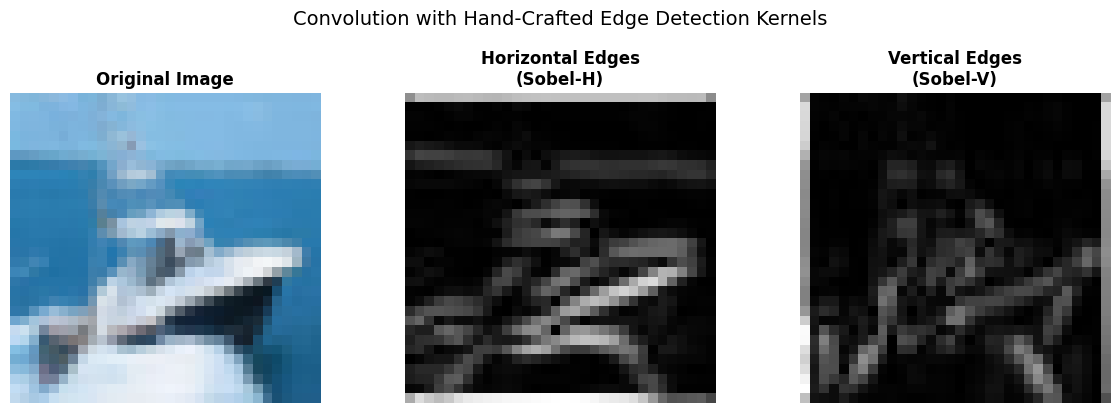

In [2]:
# ── Load one CIFAR-10 image for demonstration ─────────────────────────────────
demo_dataset = CIFAR10(root='./data', train=True, download=True,
                       transform=transforms_v2.ToTensor())

# Pick a 'ship' image (class index 8) for a clear demonstration
demo_img_tensor = None
for img, label in demo_dataset:
    if label == 8:  # ship
        demo_img_tensor = img
        break

# ── Define Sobel kernels ──────────────────────────────────────────────────────
# Horizontal Sobel: detects horizontal edges
sobel_h = torch.tensor([[-1, -2, -1],
                         [ 0,  0,  0],
                         [ 1,  2,  1]], dtype=torch.float32)

# Vertical Sobel: detects vertical edges
sobel_v = torch.tensor([[-1,  0,  1],
                         [-2,  0,  2],
                         [-1,  0,  1]], dtype=torch.float32)

# ── Convert image to grayscale for convolution demo ───────────────────────────
# Shape: [3, 32, 32] -> grayscale: [1, 1, 32, 32]
gray = demo_img_tensor.mean(dim=0, keepdim=True).unsqueeze(0)  # [1, 1, 32, 32]

# Reshape kernels for F.conv2d: [out_channels, in_channels, H, W]
k_h = sobel_h.view(1, 1, 3, 3)
k_v = sobel_v.view(1, 1, 3, 3)

# Apply convolutions with padding=1 to preserve spatial size
edge_h = F.conv2d(gray, k_h, padding=1)   # [1, 1, 32, 32]
edge_v = F.conv2d(gray, k_v, padding=1)   # [1, 1, 32, 32]

# ── Helper: tensor -> numpy for plotting ─────────────────────────────────────
def to_np(t):
    """Convert a [C, H, W] or [1, 1, H, W] tensor to a numpy array."""
    t = t.detach().squeeze().numpy()
    return t

orig_np  = demo_img_tensor.permute(1, 2, 0).numpy()  # [H, W, 3]
edge_h_np = to_np(edge_h)
edge_v_np = to_np(edge_v)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(orig_np)
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(np.abs(edge_h_np), cmap='gray')
axes[1].set_title('Horizontal Edges\n(Sobel-H)', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(np.abs(edge_v_np), cmap='gray')
axes[2].set_title('Vertical Edges\n(Sobel-V)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.suptitle('Convolution with Hand-Crafted Edge Detection Kernels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### How to Read This Chart: Convolution with Edge Detection Kernels

This chart shows three versions of the same CIFAR-10 image after applying different convolution kernels.

- **Left — Original Image:** The raw 32×32 RGB image. Despite being tiny, you can see the general shape.
- **Middle — Horizontal Edges:** The result of the horizontal Sobel filter. Bright pixels indicate a transition in pixel intensity along the **vertical direction** — meaning the filter found **horizontal lines** (think the horizon of the sea, the waterline on a ship, or the edge of a cloud). Dark areas had no horizontal edges.
- **Right — Vertical Edges:** The result of the vertical Sobel filter. Bright pixels indicate transitions along the **horizontal direction** — meaning the filter found **vertical lines** (the side of a hull, a mast, a building edge).

**What this tells us about learned filters:**  
In a trained CNN, the first layer learns filters automatically from data. Those filters end up detecting edges, blobs, and colour contrasts — very similar to Sobel filters but optimised for the specific dataset. Deeper layers combine these simple detections to recognise textures, parts, and eventually entire objects.

The key insight: **a convolution is just a pattern-matching operation**. The filter defines the pattern; the output tells you where that pattern appears in the image.

---

## Section 3 — Data Loading and Augmentation

### Why Augmentation?

A model trained on 50,000 images has seen a limited view of the world. **Data augmentation** artificially expands the training set by applying random transformations — flips, crops, colour jitter — so the model sees each image in many plausible variations. This forces the model to learn the *concept* (what a cat looks like) rather than memorising exact pixels.

The key word is *random*: every time an image is loaded during training it gets a different random transformation. This acts as a strong regulariser.

### Transforms Used

| Transform | What It Does | Why It Helps |
|-----------|-------------|-------------|
| **RandomHorizontalFlip** | Randomly mirrors the image left-right | A car facing left and right are both cars |
| **RandomCrop** | Cuts out a random 32×32 patch (after padding 4px) | Model learns to classify from partial views |
| **ColorJitter** | Randomly changes brightness, contrast, saturation, hue | Robust to lighting conditions |
| **Normalize** | Shifts pixel values to have ~zero mean and ~unit variance | Stabilises and speeds up training |

> **Note:** We use `torchvision.transforms.v2`, the modern API. The old `torchvision.transforms` API is deprecated.

Files already downloaded and verified


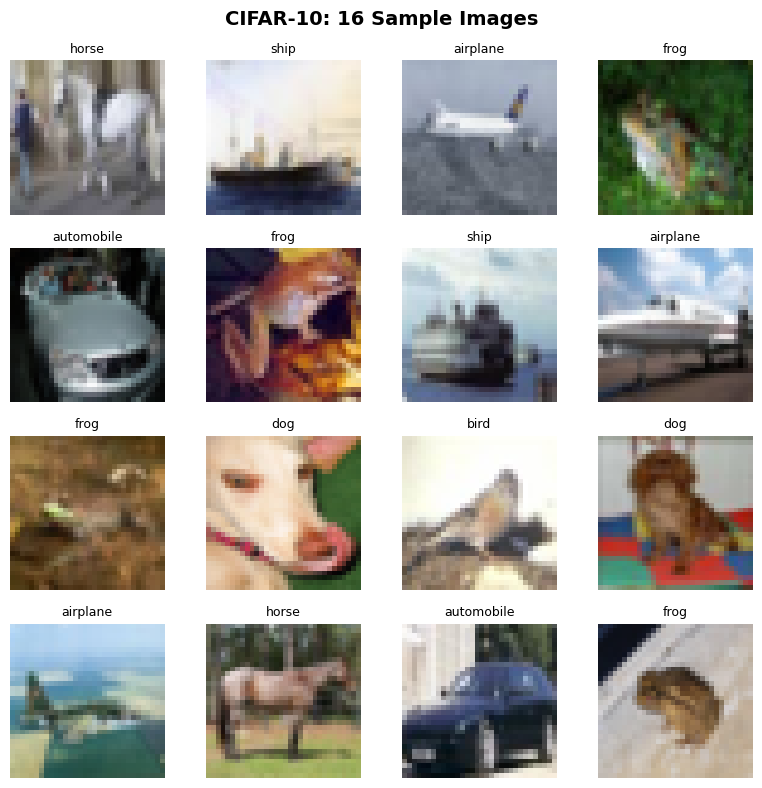

In [3]:
# ── CIFAR-10 normalisation statistics ─────────────────────────────────────────
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

# ── Load a raw (un-normalised) dataset for the grid preview ──────────────────
raw_dataset = CIFAR10(root='./data', train=True, download=True,
                      transform=transforms_v2.ToTensor())

# ── Show 16 sample images in a 4×4 grid ──────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
np.random.seed(SEED)
indices = np.random.choice(len(raw_dataset), 16, replace=False)

for ax, idx in zip(axes.flatten(), indices):
    img, label = raw_dataset[idx]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(CLASSES[label], fontsize=9)
    ax.axis('off')

plt.suptitle('CIFAR-10: 16 Sample Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

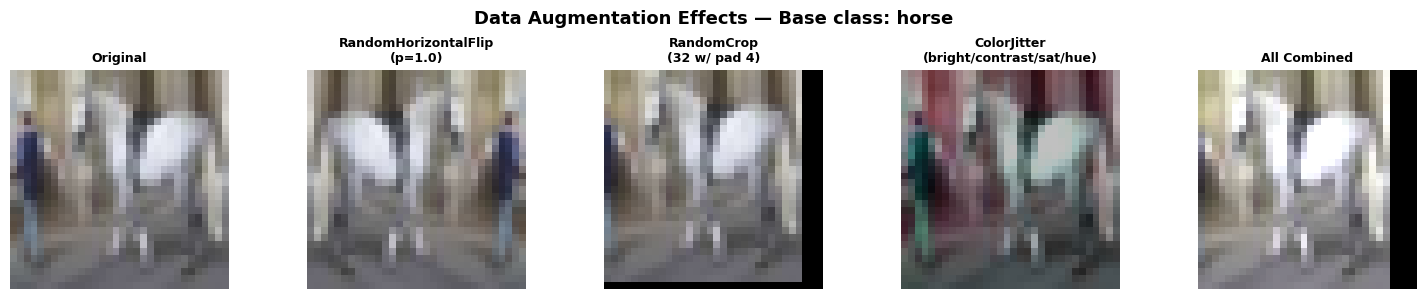

In [4]:
# ── Show the EFFECT of each augmentation on the same image ───────────────────
# Pick one base image
base_img_tensor, base_label = raw_dataset[indices[0]]
base_pil = transforms_v2.ToPILImage()(base_img_tensor)

# Define individual augmentations (no normalisation so colours stay natural)
aug_list = [
    ('Original', transforms_v2.Compose([transforms_v2.ToImage(),
                                         transforms_v2.ToDtype(torch.float32, scale=True)])),
    ('RandomHorizontalFlip\n(p=1.0)',
     transforms_v2.Compose([transforms_v2.ToImage(),
                             transforms_v2.ToDtype(torch.float32, scale=True),
                             transforms_v2.RandomHorizontalFlip(p=1.0)])),
    ('RandomCrop\n(32 w/ pad 4)',
     transforms_v2.Compose([transforms_v2.ToImage(),
                             transforms_v2.ToDtype(torch.float32, scale=True),
                             transforms_v2.Pad(4),
                             transforms_v2.RandomCrop(32)])),
    ('ColorJitter\n(bright/contrast/sat/hue)',
     transforms_v2.Compose([transforms_v2.ToImage(),
                             transforms_v2.ToDtype(torch.float32, scale=True),
                             transforms_v2.ColorJitter(brightness=0.5, contrast=0.5,
                                                        saturation=0.5, hue=0.2)])),
    ('All Combined',
     transforms_v2.Compose([transforms_v2.ToImage(),
                             transforms_v2.ToDtype(torch.float32, scale=True),
                             transforms_v2.RandomHorizontalFlip(p=0.5),
                             transforms_v2.Pad(4),
                             transforms_v2.RandomCrop(32),
                             transforms_v2.ColorJitter(brightness=0.3, contrast=0.3,
                                                        saturation=0.3, hue=0.1)])),
]

torch.manual_seed(SEED)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, (name, tfm) in zip(axes, aug_list):
    aug_img = tfm(base_pil).permute(1, 2, 0).numpy()
    aug_img = np.clip(aug_img, 0, 1)
    ax.imshow(aug_img)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'Data Augmentation Effects — Base class: {CLASSES[base_label]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: Data Augmentation Effects

Each panel shows the **same base image** with a different augmentation applied.

- **Column 1 — Original:** The unmodified image, as downloaded.
- **Column 2 — RandomHorizontalFlip:** The image is mirrored left-to-right. A car facing left becomes a car facing right. The model should recognise both — so flipping forces it to be orientation-invariant.
- **Column 3 — RandomCrop:** The image is first padded by 4 pixels on each side (to 40×40), then a random 32×32 crop is taken. This teaches the model that the object of interest might not be perfectly centred.
- **Column 4 — ColorJitter:** Brightness, contrast, saturation, and hue are randomly shifted. A ship in bright noon sunlight and a ship in overcast lighting should both be recognised as ships.
- **Column 5 — All Combined:** All augmentations applied together. This is the version of the transform used during actual training — each epoch the same image looks slightly different.

**Key insight:** Augmentation creates artificial variation without collecting new data. It is one of the most cost-effective ways to reduce overfitting. The model sees millions of slightly different versions of the training set and cannot simply memorise exact pixel patterns.

In [5]:
# ── Production transforms ─────────────────────────────────────────────────────
train_transform = transforms_v2.Compose([
    transforms_v2.ToImage(),
    transforms_v2.ToDtype(torch.float32, scale=True),
    transforms_v2.RandomHorizontalFlip(),
    transforms_v2.Pad(4),
    transforms_v2.RandomCrop(32),
    transforms_v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms_v2.Normalize(MEAN, STD),
])

val_transform = transforms_v2.Compose([
    transforms_v2.ToImage(),
    transforms_v2.ToDtype(torch.float32, scale=True),
    transforms_v2.Normalize(MEAN, STD),
])

# ── Datasets and loaders ──────────────────────────────────────────────────────
train_dataset = CIFAR10(root='./data', train=True, download=True, transform=train_transform)
val_dataset   = CIFAR10(root='./data', train=False, download=True, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Training samples:   {len(train_dataset):,}')
print(f'Validation samples: {len(val_dataset):,}')
print(f'Training batches:   {len(train_loader):,}')
print(f'Validation batches: {len(val_loader):,}')

Files already downloaded and verified


Files already downloaded and verified


Training samples:   50,000
Validation samples: 10,000
Training batches:   391
Validation batches: 40


---

## Section 4 — CNN From Scratch

### Architecture Design Decisions

Our CNN follows a standard progressive pattern:

```
Input: [B, 3, 32, 32]  (batch, RGB channels, 32×32)

Conv2d(3→32, 3×3)  → BatchNorm2d → ReLU → MaxPool2d(2)  → [B, 32, 16, 16]
Conv2d(32→64, 3×3) → BatchNorm2d → ReLU → MaxPool2d(2)  → [B, 64, 8, 8]
Conv2d(64→128, 3×3)→ BatchNorm2d → ReLU                 → [B, 128, 8, 8]
AdaptiveAvgPool2d(1)                                      → [B, 128, 1, 1]
Flatten                                                   → [B, 128]
Linear(128→256) → ReLU → Dropout(0.5)
Linear(256→10)                                            → [B, 10] logits
```

**Why these choices?**

- **BatchNorm2d** — normalises activations within each mini-batch. This prevents the "internal covariate shift" problem, allows higher learning rates, and makes training dramatically more stable.
- **ReLU** — the most popular activation function. Simple, fast, and avoids the vanishing gradient problem.
- **MaxPool2d(2)** — halves the spatial dimensions, making the network translation-tolerant and reducing computation.
- **AdaptiveAvgPool2d(1)** — reduces each feature map to a single number (global average). This makes the network input-size-agnostic.
- **Dropout(0.5)** — randomly zeros half the neurons during training. Forces redundancy in the learned representations and reduces overfitting.

### Training Strategy

- **Optimizer: Adam** — adaptive learning rate, works well out of the box for image classification
- **Loss: CrossEntropyLoss** — standard choice for multi-class classification
- **Scheduler: CosineAnnealingLR** — gradually reduces the learning rate following a cosine curve. Avoids getting stuck near the end of training and often gives a performance boost in the last few epochs.

In [6]:
# ── CNN Architecture ─────────────────────────────────────────────────────────
class SimpleCNN(nn.Module):
    """A three-block CNN for CIFAR-10 classification."""

    def __init__(self, num_classes=10):
        super().__init__()

        # Block 1: 3 → 32 channels, 32×32 → 16×16
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(2),          # 32×32 → 16×16
        )

        # Block 2: 32 → 64 channels, 16×16 → 8×8
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(2),          # 16×16 → 8×8
        )

        # Block 3: 64 → 128 channels, spatial size unchanged
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=False),
        )

        # Global pooling + classifier
        self.pool   = nn.AdaptiveAvgPool2d(1)   # 8×8 → 1×1
        self.fc1    = nn.Linear(128, 256)
        self.drop   = nn.Dropout(0.5)
        self.fc2    = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)            # [B, 32, 16, 16]
        x = self.block2(x)            # [B, 64, 8, 8]
        x = self.block3(x)            # [B, 128, 8, 8]
        x = self.pool(x)              # [B, 128, 1, 1]
        x = x.view(x.size(0), -1)     # [B, 128]
        x = F.relu(self.fc1(x))       # [B, 256]
        x = self.drop(x)
        x = self.fc2(x)               # [B, 10]
        return x

    def get_block1_features(self, x):
        """Return intermediate feature maps from block 1."""
        return self.block1(x)

    def get_block2_features(self, x):
        """Return intermediate feature maps from block 2."""
        return self.block2(self.block1(x))

# ── Instantiate and summarise ─────────────────────────────────────────────────
scratch_model = SimpleCNN(num_classes=10).to(DEVICE)

total_params     = sum(p.numel() for p in scratch_model.parameters())
trainable_params = sum(p.numel() for p in scratch_model.parameters() if p.requires_grad)

print('Model Architecture:')
print(scratch_model)
print(f'\nTotal parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Model Architecture:
SimpleCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=128, out_features=256, bias=True)
  (drop): Dropout(p=0.5, inplace=Fa

In [7]:
# ── Training utilities ────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


print('Training utilities defined.')

Training utilities defined.


In [8]:
# ── Train the scratch CNN for 30 epochs ──────────────────────────────────────
EPOCHS_SCRATCH = 30   # full training run

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(scratch_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_SCRATCH)

scratch_history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

print(f'Training SimpleCNN from scratch for {EPOCHS_SCRATCH} epochs...')
print(f'Device: {DEVICE}')
print('─' * 65)
print(f'{"Epoch":>5} {"Train Loss":>11} {"Val Loss":>10} {"Train Acc":>10} {"Val Acc":>9}')
print('─' * 65)

for epoch in range(1, EPOCHS_SCRATCH + 1):
    tr_loss, tr_acc = train_one_epoch(scratch_model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_acc = evaluate(scratch_model, val_loader, criterion, DEVICE)
    scheduler.step()

    scratch_history['train_loss'].append(tr_loss)
    scratch_history['val_loss'].append(vl_loss)
    scratch_history['train_acc'].append(tr_acc)
    scratch_history['val_acc'].append(vl_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>5}  {tr_loss:>10.4f}  {vl_loss:>9.4f}  '
              f'{tr_acc*100:>9.2f}%  {vl_acc*100:>8.2f}%')

print('─' * 65)
print(f'Final val accuracy: {scratch_history["val_acc"][-1]*100:.2f}%')

Training SimpleCNN from scratch for 30 epochs...
Device: cuda
─────────────────────────────────────────────────────────────────
Epoch  Train Loss   Val Loss  Train Acc   Val Acc
─────────────────────────────────────────────────────────────────


    1      1.6427     1.3341      38.74%     50.84%


    5      1.0921     1.0503      61.09%     62.55%


   10      0.9042     0.8935      68.28%     67.30%


   15      0.7966     0.7704      72.35%     73.01%


   20      0.7170     0.7005      75.09%     74.88%


   25      0.6686     0.6314      76.96%     77.97%


   30      0.6485     0.6096      77.55%     78.96%
─────────────────────────────────────────────────────────────────
Final val accuracy: 78.96%


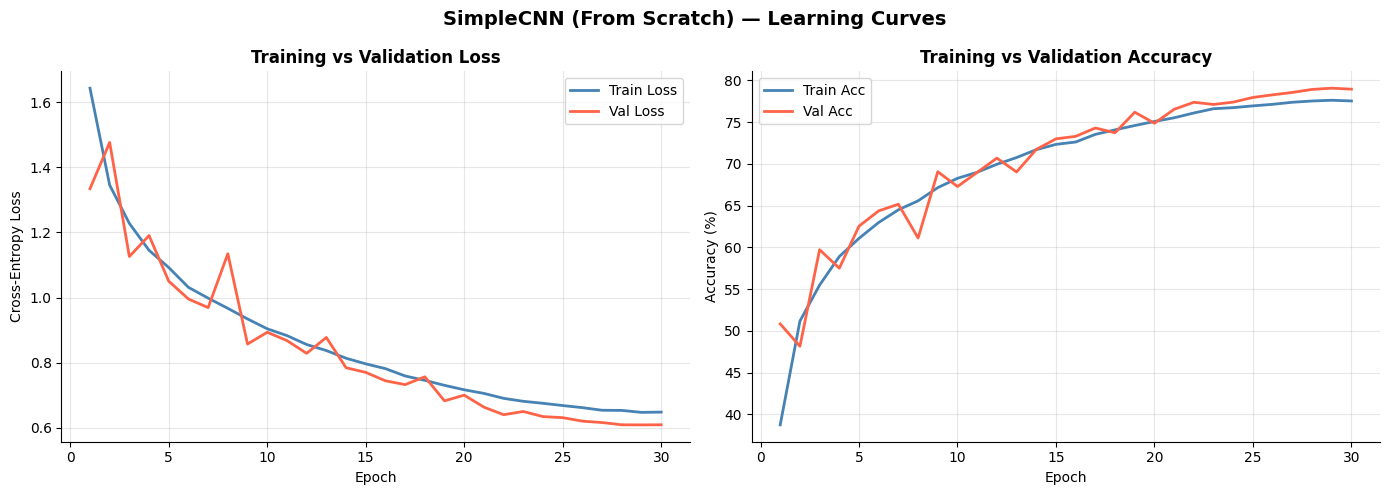

In [9]:
# ── Plot learning curves ──────────────────────────────────────────────────────
epochs = range(1, EPOCHS_SCRATCH + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs, scratch_history['train_loss'], label='Train Loss', color='steelblue', lw=2)
ax1.plot(epochs, scratch_history['val_loss'],   label='Val Loss',   color='tomato',    lw=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training vs Validation Loss', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs, [a*100 for a in scratch_history['train_acc']],
         label='Train Acc', color='steelblue', lw=2)
ax2.plot(epochs, [a*100 for a in scratch_history['val_acc']],
         label='Val Acc',   color='tomato',    lw=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training vs Validation Accuracy', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('SimpleCNN (From Scratch) — Learning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: CNN Training Curves

Two subplots, each showing two lines — one for training data (blue) and one for validation data (red).

**Left — Loss curves:**
- Loss measures how wrong the model is. Lower is better.
- Both lines should trend **downward** over time. If training loss goes down but validation loss stops improving (or rises), that is **overfitting** — the model is memorising training data.
- The CosineAnnealingLR scheduler causes the learning rate to decrease smoothly, which often shows up as a gentle "settling" of the loss curve toward the end.

**Right — Accuracy curves:**
- Accuracy is the percentage of images classified correctly. Higher is better.
- Both lines should trend **upward**. A gap between training and validation accuracy indicates overfitting.
- Watch for the point where validation accuracy plateaus — that tells you roughly how many epochs you actually need.

**What counts as good?**  
With this simple 3-block CNN and 30 epochs of training, you can expect roughly **75–82% validation accuracy** on CIFAR-10. The state of the art is above 99%, but that requires much deeper networks (ResNet, EfficientNet) and longer training.

---

## Section 5 — Feature Map Visualization

### What Are Feature Maps?

After training, we can pass an image through the network and **intercept the output at each layer**. Those outputs are called **feature maps** (or **activation maps**). Each filter in a layer produces one feature map, and each map is the filter's "view" of the input.

- **Early layers** (Block 1): detect edges, colour gradients, blobs — low-level visual primitives
- **Middle layers** (Block 2): combine primitives into textures, corners, patterns
- **Deep layers** (Block 3): detect high-level structures like wheels, eyes, wings

Visualising feature maps is one of the best ways to develop intuition for what a CNN is actually doing.

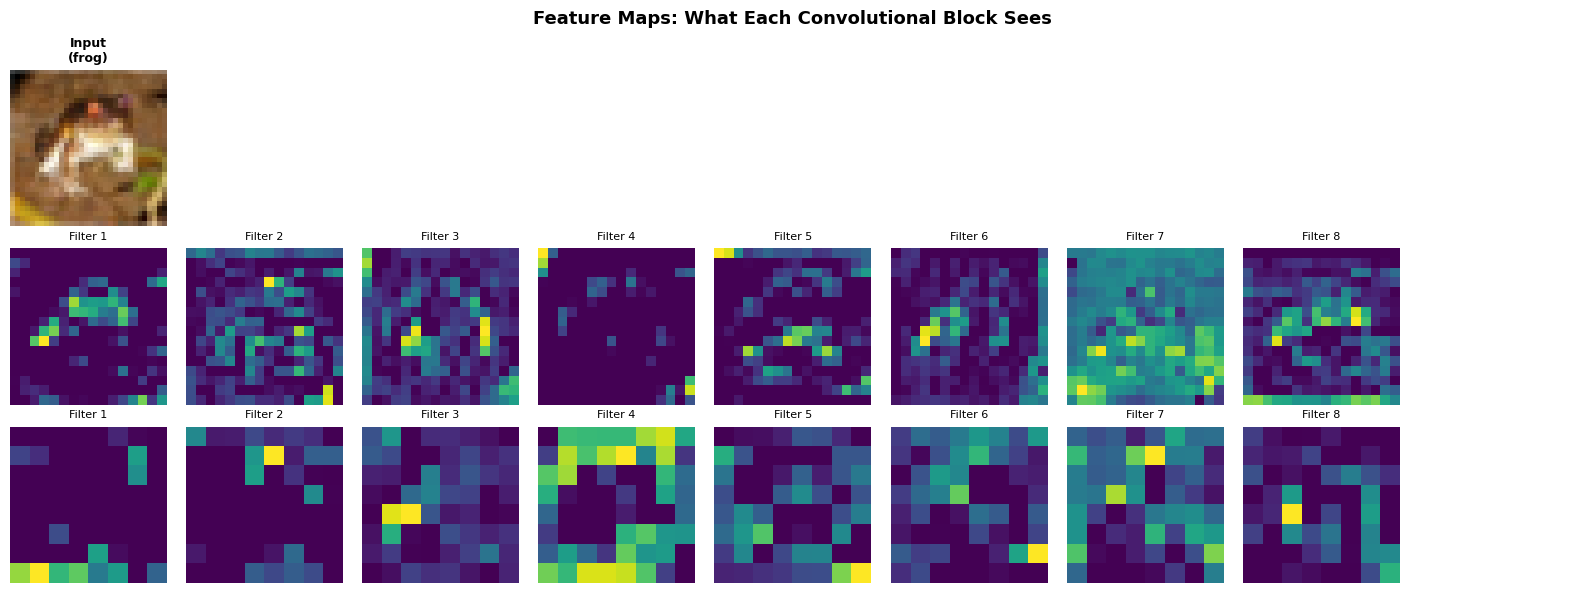

In [10]:
# ── Pick one test image for feature map visualization ────────────────────────
viz_img_tensor, viz_label = raw_dataset[0]   # raw (unnormalized) for display

# Normalised version for model input
normalise = transforms_v2.Compose([
    transforms_v2.ToImage(),
    transforms_v2.ToDtype(torch.float32, scale=True),
    transforms_v2.Normalize(MEAN, STD),
])
from PIL import Image as PILImage
viz_pil = transforms_v2.ToPILImage()(viz_img_tensor)
viz_input = normalise(viz_pil).unsqueeze(0).to(DEVICE)  # [1, 3, 32, 32]

# ── Extract feature maps ──────────────────────────────────────────────────────
scratch_model.eval()
with torch.no_grad():
    fmap1 = scratch_model.get_block1_features(viz_input).squeeze(0).cpu()  # [32, 16, 16]
    fmap2 = scratch_model.get_block2_features(viz_input).squeeze(0).cpu()  # [64, 8, 8]

# ── Plot: input + 8 Block-1 maps + 8 Block-2 maps ────────────────────────────
N_SHOW = 8

fig = plt.figure(figsize=(16, 6))

# Row 1: original image
ax = fig.add_subplot(3, N_SHOW + 1, 1)
ax.imshow(viz_img_tensor.permute(1, 2, 0).numpy())
ax.set_title(f'Input\n({CLASSES[viz_label]})', fontsize=9, fontweight='bold')
ax.axis('off')
for j in range(2, N_SHOW + 2):
    fig.add_subplot(3, N_SHOW + 1, j).axis('off')

# Row 2: Block-1 feature maps
for i in range(N_SHOW):
    ax = fig.add_subplot(3, N_SHOW + 1, (N_SHOW + 1) + i + 1)
    ax.imshow(fmap1[i].numpy(), cmap='viridis')
    if i == 0:
        ax.set_ylabel('Block 1\n(Conv1)', fontsize=9, fontweight='bold')
    ax.set_title(f'Filter {i+1}', fontsize=8)
    ax.axis('off')

# Row 3: Block-2 feature maps
for i in range(N_SHOW):
    ax = fig.add_subplot(3, N_SHOW + 1, 2*(N_SHOW + 1) + i + 1)
    ax.imshow(fmap2[i].numpy(), cmap='viridis')
    if i == 0:
        ax.set_ylabel('Block 2\n(Conv2)', fontsize=9, fontweight='bold')
    ax.set_title(f'Filter {i+1}', fontsize=8)
    ax.axis('off')

plt.suptitle('Feature Maps: What Each Convolutional Block Sees', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: Feature Maps

Three rows of images, all derived from a single input image.

- **Row 1 — Input Image:** The original 32×32 CIFAR-10 image that is fed to the network.
- **Row 2 — Block 1 Feature Maps (8 of 32 filters):** Each panel shows the output of one filter in the first convolutional block. These are 16×16 maps (the image has been downsampled by MaxPool). The colour scale runs from dark (low activation) to bright yellow (high activation).
- **Row 3 — Block 2 Feature Maps (8 of 64 filters):** Each panel shows the output of one filter in the second convolutional block. These are 8×8 maps.

**What to notice:**
- **Block 1 maps** tend to look like edge and colour detectors. Some filters light up on horizontal edges, others on vertical edges, others on specific colour patches. You can often still recognise the rough shape of the original image.
- **Block 2 maps** are more abstract. The spatial structure is smaller (8×8), and the activations respond to combinations of features from Block 1. It becomes harder to visually connect them to the original image — the network is encoding higher-level patterns.
- **Bright (active) vs dark (inactive):** Dark areas mean the filter did not find its pattern there. Bright areas mean it found a strong match. A filter that is entirely dark for this image simply encodes a pattern that does not appear in this particular image.

---

## Section 6 — Grad-CAM (Gradient-weighted Class Activation Mapping)

### The Problem Grad-CAM Solves

CNNs are powerful but historically opaque — you get a prediction but no explanation. **Grad-CAM answers the question: *WHERE* in the image was the model looking when it made this prediction?**

This is essential for debugging:
- If the model says "cat" but is looking at the background couch, something is wrong.
- If the model says "ship" but is looking at the water rather than the hull, it might be learning a spurious correlation.

### How Grad-CAM Works (Step by Step)

1. **Forward pass** — run the image through the network, get the class score.
2. **Register a hook** — intercept the feature maps at the last convolutional layer.
3. **Backward pass** — compute gradients of the target class score with respect to those feature maps.
4. **Weight the maps** — take the global average of the gradients across each feature map. This gives an importance weight for each filter.
5. **Weighted sum** — multiply each feature map by its importance weight, sum them up, apply ReLU (keep only positive contributions).
6. **Overlay** — resize the resulting heatmap to the original image size and overlay it transparently.

The bright (warm) regions in the final overlay are where the model's attention was concentrated for that specific prediction.

In [11]:
# ── Grad-CAM implementation ───────────────────────────────────────────────────
class GradCAM:
    """Minimal Grad-CAM implementation using forward/backward hooks."""

    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        # Register hooks on the target layer, keeping the handles so they can be
        # removed later (re-registering on every instance would otherwise leak hooks).
        self._handles = [
            target_layer.register_forward_hook(self._save_activation),
            target_layer.register_full_backward_hook(self._save_gradient),
        ]

    def remove(self):
        """Detach the forward/backward hooks."""
        for h in self._handles:
            h.remove()
        self._handles = []

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        """
        Run a forward+backward pass and return a Grad-CAM heatmap.
        input_tensor: [1, C, H, W]
        Returns heatmap as numpy array [H, W] scaled to [0, 1].
        """
        self.model.eval()
        self.model.zero_grad()

        output = self.model(input_tensor)   # [1, num_classes]
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Backward on the target class score
        score = output[0, class_idx]
        score.backward()

        # Global average pool the gradients: [C, H, W] → [C]
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]

        # Weighted combination of activation maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # [1, 1, H, W]
        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()

        # Normalise to [0, 1]
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam, class_idx


def overlay_cam(raw_img_np, cam, alpha=0.45):
    """
    Blend a Grad-CAM heatmap with the original image.
    raw_img_np: [H, W, 3] float32 in [0, 1]
    cam: [h, w] float32 in [0, 1]
    """
    # Bilinear resize via torch (no cv2 dependency)
    cam_t = torch.tensor(cam, dtype=torch.float32)[None, None]  # [1,1,h,w]
    cam_resized = F.interpolate(cam_t, size=(raw_img_np.shape[0], raw_img_np.shape[1]),
                                mode="bilinear", align_corners=False)[0, 0].numpy()

    heatmap = cm.jet(cam_resized)[:, :, :3]  # [H, W, 3], values in [0,1]
    overlay = (1 - alpha) * raw_img_np + alpha * heatmap
    return np.clip(overlay, 0, 1)


print('Grad-CAM class and overlay helper defined.')

Grad-CAM class and overlay helper defined.


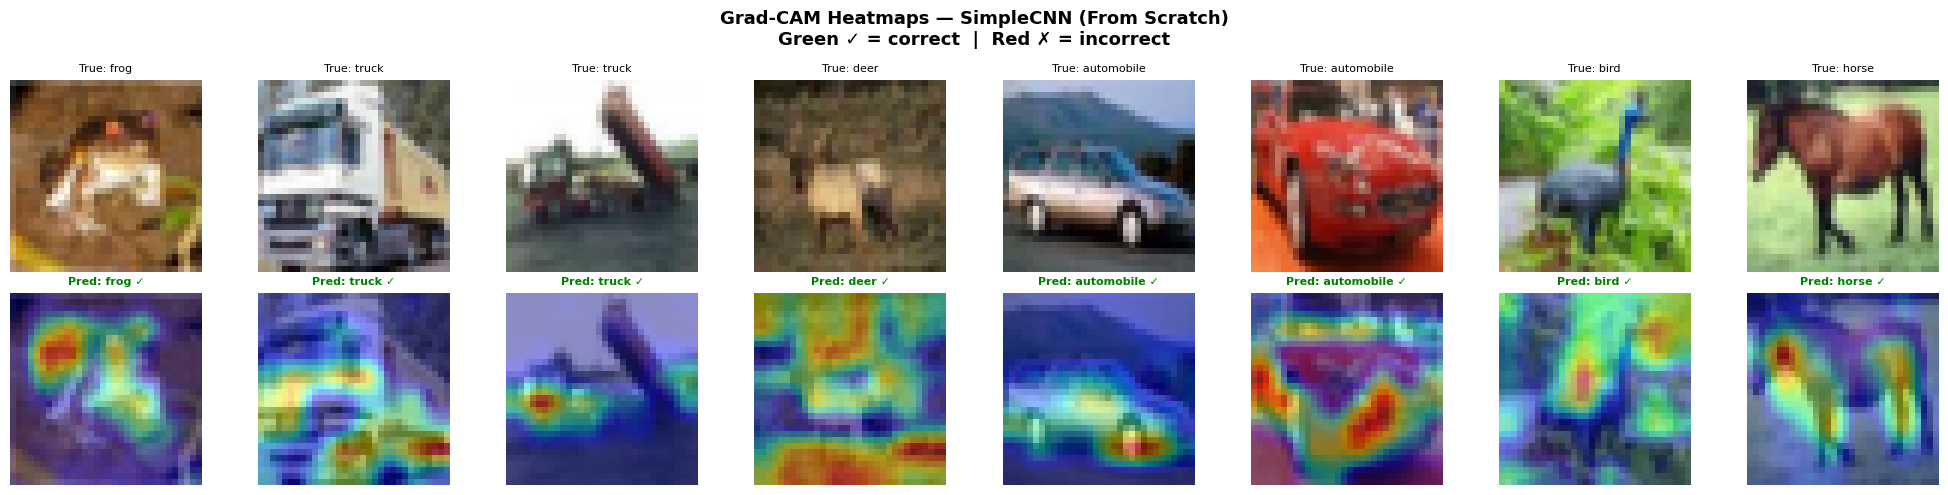

In [12]:
# ── Attach Grad-CAM to the last conv layer (block3's BatchNorm/ReLU output) ──
# The last ReLU in block3 is block3[2]
gradcam_scratch = GradCAM(scratch_model, scratch_model.block3[2])

# ── Collect 8 test images (mix of correct and incorrect predictions) ──────────
test_imgs_raw   = []
test_imgs_norm  = []
test_true_labels = []

count = 0
for raw_img, label in raw_dataset:
    pil_img = transforms_v2.ToPILImage()(raw_img)
    norm_img = normalise(pil_img)
    test_imgs_raw.append(raw_img.permute(1, 2, 0).numpy())  # [H, W, 3]
    test_imgs_norm.append(norm_img)
    test_true_labels.append(label)
    count += 1
    if count == 8:
        break

# ── Generate Grad-CAM heatmaps ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(20, 5))

for i in range(8):
    inp = test_imgs_norm[i].unsqueeze(0).to(DEVICE)
    cam, pred_idx = gradcam_scratch.generate(inp)
    true_idx = test_true_labels[i]
    is_correct = (pred_idx == true_idx)
    status = '✓' if is_correct else '✗'
    color  = 'green' if is_correct else 'red'

    overlay = overlay_cam(test_imgs_raw[i], cam)

    # Top row: original
    axes[0, i].imshow(test_imgs_raw[i])
    axes[0, i].set_title(f'True: {CLASSES[true_idx]}', fontsize=8)
    axes[0, i].axis('off')

    # Bottom row: Grad-CAM overlay
    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f'Pred: {CLASSES[pred_idx]} {status}',
                         fontsize=8, color=color, fontweight='bold')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9, fontweight='bold')
axes[1, 0].set_ylabel('Grad-CAM', fontsize=9, fontweight='bold')

plt.suptitle('Grad-CAM Heatmaps — SimpleCNN (From Scratch)\nGreen ✓ = correct  |  Red ✗ = incorrect',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: Grad-CAM Heatmaps

Two rows of 8 images, each column showing the same test image.

- **Top row — Original Image:** The unmodified test image with the true class label.
- **Bottom row — Grad-CAM Overlay:** The same image with a colour heatmap blended over it. The prediction label is shown in green (correct) or red (incorrect).

**Reading the colour scale:**
- **Red/orange/warm = high attention** — these are the pixels the model focused on most when making its prediction.
- **Blue/green/cool = low attention** — these regions were largely ignored.

**What to look for:**
- On **correct predictions**, the warm region should overlap with the actual object. If the model predicts "ship" correctly, the heat should be on the ship's hull, not on the sky.
- On **incorrect predictions**, look at where the heat is. Is the model looking at the wrong object? At the background? This reveals what feature misled it. This kind of analysis is called **failure mode debugging** and is one of the most practical uses of Grad-CAM.
- From-scratch models often show diffuse or background-heavy attention, especially early in training — the model hasn't yet learned to focus on the semantically important parts of images.

---

## Section 7 — Transfer Learning with ResNet-18

### What Is Transfer Learning?

**Transfer learning uses a model pre-trained on millions of images (ImageNet) and fine-tunes it on your specific task.** The pre-trained model already knows how to detect edges, textures, shapes, and objects — we just teach it the new class distinctions.

Think of it like hiring an expert photographer who already knows the basics of composition, lighting, and colour theory. You just need to teach them the specific subjects your project needs.

### Why ResNet-18?

ResNet-18 is a classic 18-layer residual network trained on ImageNet (1.2 million images, 1,000 classes). It introduced the **skip connection** (residual connection), which lets gradients flow directly through the network, making very deep networks trainable.

ResNet-18 is a good starting point because:
- It is small enough to run quickly, even on CPU
- Pre-trained weights are freely available
- The architecture generalises well to new tasks

### Two Phases of Fine-Tuning

**Phase 1 — Frozen Backbone (10 epochs):**  
We freeze all layers except the final fully connected (fc) layer. Only the new classification head is trained. This is fast and avoids destroying the pre-trained features.

**Phase 2 — Full Fine-Tuning (10 more epochs):**  
We unfreeze all layers. Now the entire network adapts to CIFAR-10 with a small learning rate. This squeezes out more performance because all layers can specialise to the new domain.

In [13]:
# ── Load ResNet-18 with ImageNet pre-trained weights ──────────────────────────
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# ── Replace the final FC layer for 10 CIFAR-10 classes ───────────────────────
# Original: Linear(512, 1000) → New: Linear(512, 10)
in_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(in_features, 10)

# ── Phase 1: Freeze all layers except the new fc head ────────────────────────
for name, param in resnet18.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False

resnet18 = resnet18.to(DEVICE)

# Count parameters
total_p     = sum(p.numel() for p in resnet18.parameters())
trainable_p = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
print(f'Total parameters:     {total_p:,}')
print(f'Trainable parameters (Phase 1): {trainable_p:,}')
print(f'Frozen parameters:    {total_p - trainable_p:,}')

# CIFAR-10 images are 32×32; ResNet-18 expects 224×224
# We add a resize transform for ResNet
resnet_train_transform = transforms_v2.Compose([
    transforms_v2.ToImage(),
    transforms_v2.ToDtype(torch.float32, scale=True),
    transforms_v2.Resize(224, antialias=True),
    transforms_v2.RandomHorizontalFlip(),
    transforms_v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms_v2.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                              std=[0.229, 0.224, 0.225]),
])

resnet_val_transform = transforms_v2.Compose([
    transforms_v2.ToImage(),
    transforms_v2.ToDtype(torch.float32, scale=True),
    transforms_v2.Resize(224, antialias=True),
    transforms_v2.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225]),
])

resnet_train_ds = CIFAR10(root='./data', train=True, download=True, transform=resnet_train_transform)
resnet_val_ds   = CIFAR10(root='./data', train=False, download=True, transform=resnet_val_transform)

resnet_train_loader = DataLoader(resnet_train_ds, batch_size=64, shuffle=True,  num_workers=0)
resnet_val_loader   = DataLoader(resnet_val_ds,   batch_size=128, shuffle=False, num_workers=0)

print('ResNet-18 and data loaders ready.')

Total parameters:     11,181,642
Trainable parameters (Phase 1): 5,130
Frozen parameters:    11,176,512


Files already downloaded and verified


Files already downloaded and verified


ResNet-18 and data loaders ready.


In [14]:
# ── Phase 1: Train only the new fc head (frozen backbone) ────────────────────
EPOCHS_FROZEN = 10   # frozen-backbone warmup

criterion_rn = nn.CrossEntropyLoss()
optimizer_rn = optim.Adam(filter(lambda p: p.requires_grad, resnet18.parameters()),
                           lr=1e-3)

frozen_history = {'train_acc': [], 'val_acc': []}

print('Phase 1 — Frozen backbone, training head only')
print('─' * 55)
print(f'{"Epoch":>5} {"Train Acc":>11} {"Val Acc":>10}')
print('─' * 55)

for epoch in range(1, EPOCHS_FROZEN + 1):
    tr_loss, tr_acc = train_one_epoch(resnet18, resnet_train_loader,
                                       optimizer_rn, criterion_rn, DEVICE)
    vl_loss, vl_acc = evaluate(resnet18, resnet_val_loader, criterion_rn, DEVICE)

    frozen_history['train_acc'].append(tr_acc)
    frozen_history['val_acc'].append(vl_acc)

    print(f'{epoch:>5}  {tr_acc*100:>10.2f}%  {vl_acc*100:>9.2f}%')

print('─' * 55)
print(f'Phase 1 final val accuracy: {frozen_history["val_acc"][-1]*100:.2f}%')

Phase 1 — Frozen backbone, training head only
───────────────────────────────────────────────────────
Epoch   Train Acc    Val Acc
───────────────────────────────────────────────────────


    1       70.10%      78.36%


    2       75.62%      79.28%


    3       76.56%      79.07%


    4       76.90%      79.91%


...

    6       77.33%      78.93%


    7       77.56%      79.46%


    8       77.72%      78.82%


    9       77.96%      80.02%


   10       77.73%      80.13%
───────────────────────────────────────────────────────
Phase 1 final val accuracy: 80.13%


In [15]:
# ── Phase 2: Unfreeze ALL layers for full fine-tuning ─────────────────────────
for param in resnet18.parameters():
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
print(f'Trainable parameters (Phase 2 — all): {trainable_p2:,}')

EPOCHS_FULL = 10   # full fine-tuning
# Lower learning rate for full fine-tuning — avoid destroying pre-trained features
optimizer_rn_full = optim.Adam(resnet18.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_rn_full = optim.lr_scheduler.CosineAnnealingLR(optimizer_rn_full, T_max=EPOCHS_FULL)

finetune_history = {'train_acc': [], 'val_acc': []}

print('Phase 2 — Full fine-tuning (all layers unfrozen)')
print('─' * 55)
print(f'{"Epoch":>5} {"Train Acc":>11} {"Val Acc":>10}')
print('─' * 55)

for epoch in range(1, EPOCHS_FULL + 1):
    tr_loss, tr_acc = train_one_epoch(resnet18, resnet_train_loader,
                                       optimizer_rn_full, criterion_rn, DEVICE)
    vl_loss, vl_acc = evaluate(resnet18, resnet_val_loader, criterion_rn, DEVICE)
    scheduler_rn_full.step()

    finetune_history['train_acc'].append(tr_acc)
    finetune_history['val_acc'].append(vl_acc)

    print(f'{epoch:>5}  {tr_acc*100:>10.2f}%  {vl_acc*100:>9.2f}%')

print('─' * 55)
print(f'Phase 2 final val accuracy: {finetune_history["val_acc"][-1]*100:.2f}%')

Trainable parameters (Phase 2 — all): 11,181,642
Phase 2 — Full fine-tuning (all layers unfrozen)
───────────────────────────────────────────────────────
Epoch   Train Acc    Val Acc
───────────────────────────────────────────────────────


    1       88.81%      93.31%


    2       94.45%      93.90%


    3       96.42%      93.98%


    4       97.59%      94.66%


...

    6       98.97%      95.33%


    7       99.49%      95.76%


    8       99.69%      95.91%


    9       99.82%      96.09%


   10       99.89%      96.12%
───────────────────────────────────────────────────────
Phase 2 final val accuracy: 96.12%


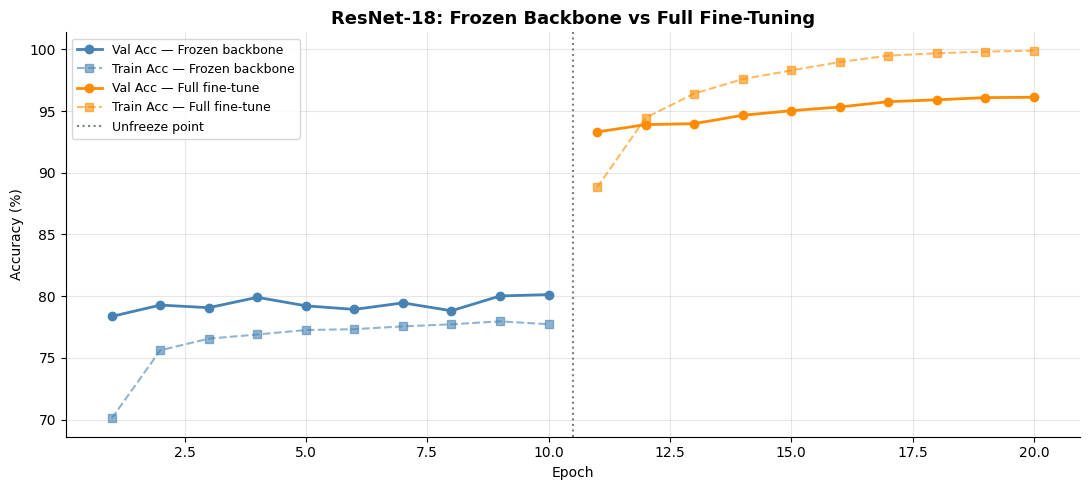

In [16]:
# ── Plot frozen vs full fine-tuning ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

e_frozen   = range(1, EPOCHS_FROZEN + 1)
e_full     = range(EPOCHS_FROZEN + 1, EPOCHS_FROZEN + EPOCHS_FULL + 1)

ax.plot(e_frozen, [a*100 for a in frozen_history['val_acc']],
        'o-', color='steelblue', lw=2, label='Val Acc — Frozen backbone')
ax.plot(e_frozen, [a*100 for a in frozen_history['train_acc']],
        's--', color='steelblue', lw=1.5, alpha=0.6, label='Train Acc — Frozen backbone')
ax.plot(e_full, [a*100 for a in finetune_history['val_acc']],
        'o-', color='darkorange', lw=2, label='Val Acc — Full fine-tune')
ax.plot(e_full, [a*100 for a in finetune_history['train_acc']],
        's--', color='darkorange', lw=1.5, alpha=0.6, label='Train Acc — Full fine-tune')

ax.axvline(EPOCHS_FROZEN + 0.5, color='grey', lw=1.5, linestyle=':', label='Unfreeze point')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('ResNet-18: Frozen Backbone vs Full Fine-Tuning', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### How to Read This Chart: Frozen vs Full Fine-Tuning

This chart shows accuracy across 20 epochs split into two phases, separated by the vertical dotted line.

**Left of the dotted line — Frozen Backbone (Phase 1):**
- Only the final classification head (512 → 10) is being trained.
- The blue lines. The model converges quickly because there are very few trainable parameters.
- Validation accuracy improves rapidly in the first few epochs, then plateaus.

**Right of the dotted line — Full Fine-Tuning (Phase 2):**
- All layers are unlocked. Every weight in the network adjusts to CIFAR-10.
- The orange lines. Notice that validation accuracy typically climbs further — the pre-trained backbone features are now adapting to the CIFAR-10 domain specifically.
- A lower learning rate (1e-4 vs 1e-3) is used to avoid catastrophically overwriting the valuable pre-trained weights.

**Key insight:** Frozen training is a fast, low-risk starting point. Full fine-tuning extracts more performance but risks overfitting on small datasets and takes longer to train.

---

## Section 8 — Training From Scratch vs Transfer Learning: Convergence Comparison

This is the "why transfer learning" chart. We plot accuracy curves for both models on the same axes to make the advantage of pre-trained features immediately visible.

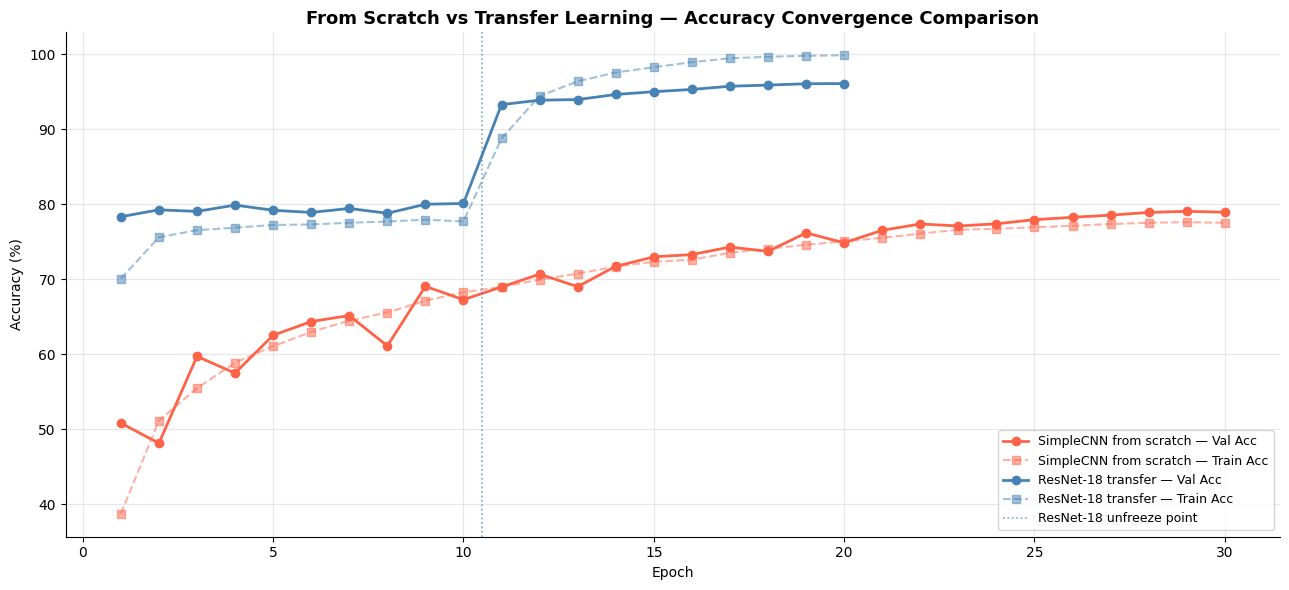

SimpleCNN final val accuracy (30 epochs):     78.96%
ResNet-18 final val accuracy (20 epochs):     96.12%


In [17]:
# ── Build combined accuracy curves ───────────────────────────────────────────
# ResNet full history (frozen + fine-tuned)
resnet_val_full   = frozen_history['val_acc']   + finetune_history['val_acc']
resnet_train_full = frozen_history['train_acc'] + finetune_history['train_acc']

# Scratch CNN history (30 epochs)
scratch_val   = scratch_history['val_acc']
scratch_train = scratch_history['train_acc']

e_resnet = range(1, len(resnet_val_full) + 1)
e_scratch = range(1, len(scratch_val) + 1)

fig, ax = plt.subplots(figsize=(13, 6))

# Scratch CNN
ax.plot(e_scratch, [a*100 for a in scratch_val],
        'o-', color='tomato', lw=2, label='SimpleCNN from scratch — Val Acc')
ax.plot(e_scratch, [a*100 for a in scratch_train],
        's--', color='tomato', lw=1.5, alpha=0.5, label='SimpleCNN from scratch — Train Acc')

# ResNet-18 transfer
ax.plot(e_resnet, [a*100 for a in resnet_val_full],
        'o-', color='steelblue', lw=2, label='ResNet-18 transfer — Val Acc')
ax.plot(e_resnet, [a*100 for a in resnet_train_full],
        's--', color='steelblue', lw=1.5, alpha=0.5, label='ResNet-18 transfer — Train Acc')

ax.axvline(EPOCHS_FROZEN + 0.5, color='steelblue', lw=1.2, linestyle=':',
           label='ResNet-18 unfreeze point', alpha=0.7)

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('From Scratch vs Transfer Learning — Accuracy Convergence Comparison',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'SimpleCNN final val accuracy (30 epochs):     {scratch_val[-1]*100:.2f}%')
print(f'ResNet-18 final val accuracy (20 epochs):     {resnet_val_full[-1]*100:.2f}%')

### How to Read This Chart: Scratch vs Transfer Learning

Two pairs of lines (solid = validation, dashed = training) for two models on the same accuracy axis.

- **Red lines — SimpleCNN from scratch:** Starts from random weights. Accuracy climbs slowly as it learns basic features from scratch.
- **Blue lines — ResNet-18 transfer learning:** Starts from ImageNet pre-trained weights. Accuracy is already high in epoch 1 because the model already knows how to detect edges, shapes, and textures.

**The key message:**
- Transfer learning typically achieves in **3–5 epochs** what training from scratch takes **25–30 epochs** to reach.
- The final accuracy of the transfer-learned model is also higher — it benefits from an 11-million-parameter backbone trained on 1.2 million images.
- If you are working on image classification, **always start with a pre-trained model** unless you have a strong reason not to (very unusual domain, privacy constraints, academic research purposes).

**Practical implication:** Transfer learning is not just faster — it is also less risky. With fewer epochs needed, there is less opportunity for overfitting, and you need less data.

---

## Section 9 — When to Freeze vs Fine-Tune

Transfer learning is not one-size-fits-all. The right strategy depends on two dimensions: **how much data you have** and **how similar your task is to the source domain (ImageNet)**.

### Decision Guide

| Situation | Recommended Strategy | Reasoning |
|-----------|---------------------|----------|
| **Small dataset, similar domain** (e.g., classifying dog breeds) | Freeze backbone, train head only | Pre-trained features transfer directly. Fine-tuning all layers with little data would overfit. |
| **Small dataset, different domain** (e.g., classifying medical X-rays from ImageNet) | Fine-tune top few layers only | Early layers (edge/texture detectors) still transfer. Only the higher-level features need domain adaptation. |
| **Large dataset, similar domain** | Full fine-tuning | Enough data to adapt all layers without overfitting. More accurate than frozen backbone. |
| **Large dataset, different domain** | Full fine-tuning from pretrained | Start from pre-trained weights for faster convergence but allow all layers to adapt fully. |
| **Unlimited data, standard domain** | Train from scratch (with pre-trained init still a good idea) | Pre-training still helps convergence, but full scratch training may match with enough compute. |

### Learning Rate Strategy When Fine-Tuning

A common best practice is **discriminative learning rates**: use a very small learning rate for early layers (to preserve low-level features) and a higher rate for the final layers (to adapt quickly to new classes).

```
Layer group          Learning rate
──────────────────────────────────
Early conv layers    1e-5  (tiny nudge)
Middle layers        1e-4
Last layers + head   1e-3  (normal update)
```

Libraries like **fastai** make this trivially easy; in raw PyTorch you pass multiple parameter groups to the optimizer.

### Signs of Transfer Learning Going Wrong

| Symptom | Likely Cause | Fix |
|---------|-------------|-----|
| High train acc, low val acc | Overfitting on small dataset | Freeze more layers, add dropout, reduce LR |
| Val loss explodes after unfreezing | LR too high for fine-tuning | Reduce LR by 10× before unfreezing |
| No improvement over random | Domain too far from ImageNet | Consider training from scratch or using domain-specific pre-training |
| Very slow convergence | Features don't transfer at all | Use a backbone pre-trained on a more similar domain |

---

## Section 10 — Grad-CAM on ResNet-18

Now we apply the same Grad-CAM technique to ResNet-18 and compare its attention maps to those from our simple scratch CNN. ResNet-18's deeper architecture and pre-trained features should produce more semantically focused attention.

In [18]:
# ── Attach Grad-CAM to ResNet-18's last conv layer ────────────────────────────
# ResNet-18 architecture: layer4 → avgpool → fc
# We hook layer4[1].conv2 — the last convolutional layer. Its feature maps carry
# the richest spatial information, which Grad-CAM weights by class-gradient importance.
gradcam_resnet = GradCAM(resnet18, resnet18.layer4[1].conv2)

# ── Normalise test images with ImageNet stats for ResNet ─────────────────────
resnet_normalise = transforms_v2.Compose([
    transforms_v2.ToImage(),
    transforms_v2.ToDtype(torch.float32, scale=True),
    transforms_v2.Resize(224, antialias=True),
    transforms_v2.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225]),
])

# Collect the same 8 test images (same indices as before)
resnet_test_norm = []
count = 0
for raw_img, label in raw_dataset:
    pil_img = transforms_v2.ToPILImage()(raw_img)
    norm_img = resnet_normalise(pil_img)
    resnet_test_norm.append(norm_img)
    count += 1
    if count == 8:
        break

print('ResNet-18 Grad-CAM hooks registered.')

ResNet-18 Grad-CAM hooks registered.


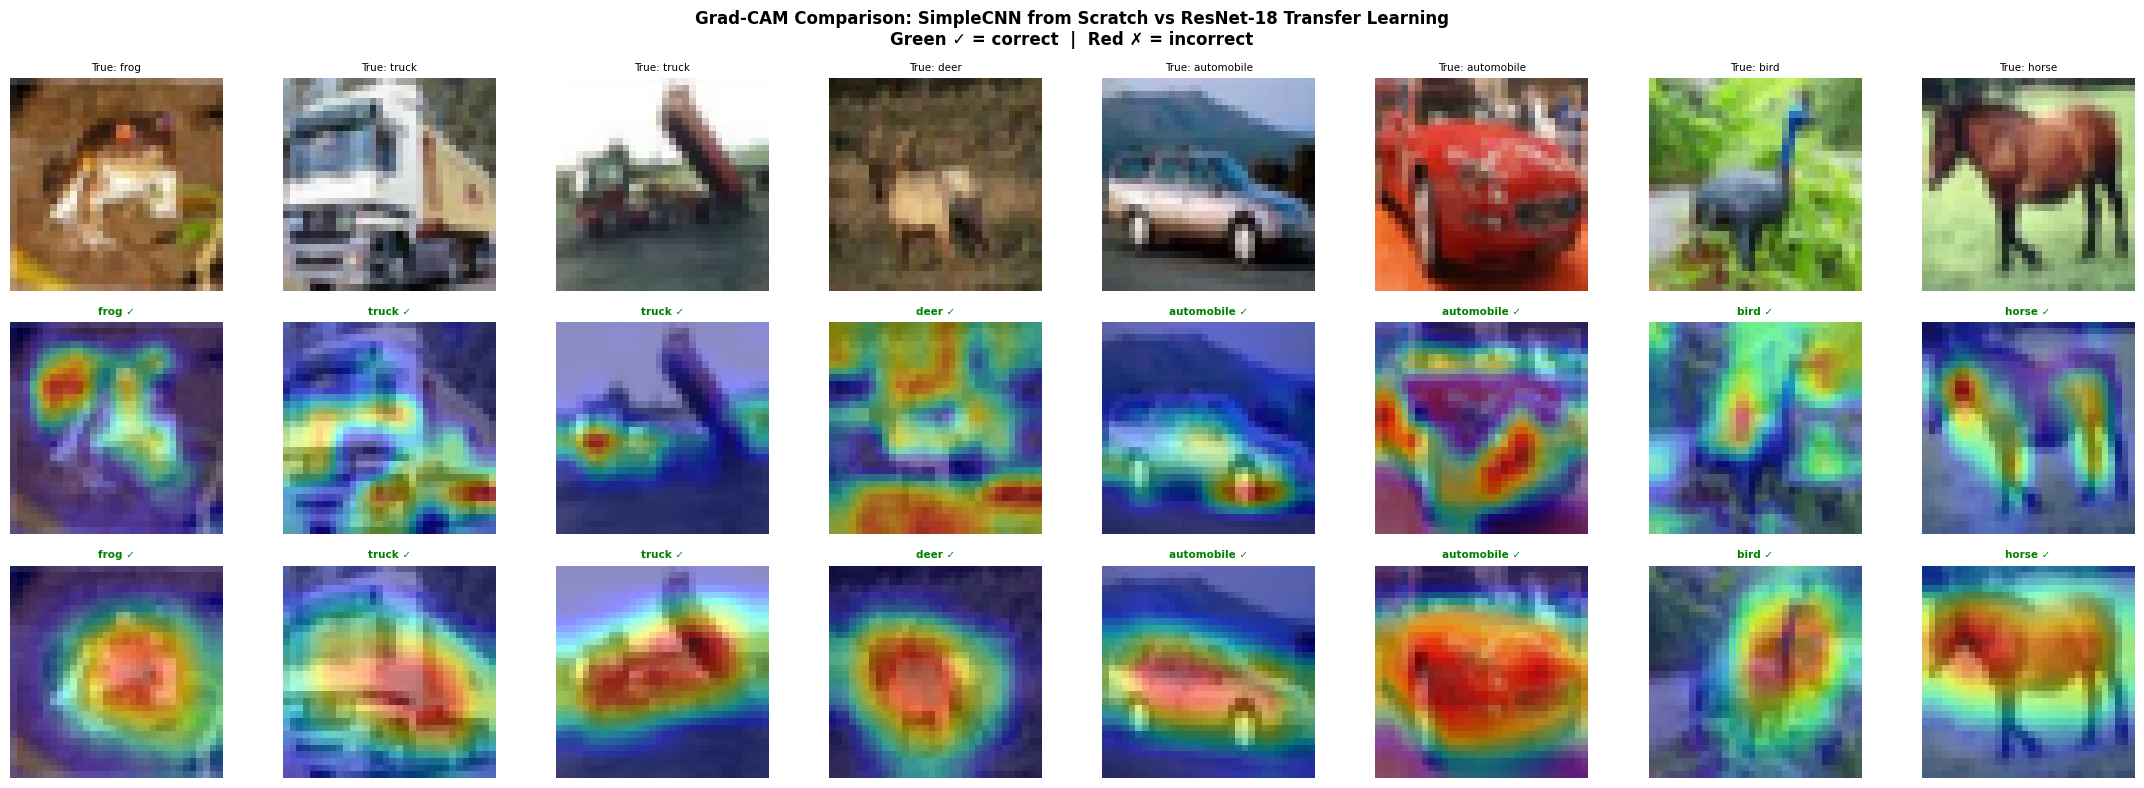

In [19]:
# ── Side-by-side Grad-CAM comparison: SimpleCNN vs ResNet-18 ─────────────────
fig, axes = plt.subplots(3, 8, figsize=(22, 8))

for i in range(8):
    true_idx = test_true_labels[i]
    raw_np   = test_imgs_raw[i]   # [H, W, 3] in [0,1]

    # Row 1: original
    axes[0, i].imshow(raw_np)
    axes[0, i].set_title(f'True: {CLASSES[true_idx]}', fontsize=7.5)
    axes[0, i].axis('off')

    # Row 2: SimpleCNN Grad-CAM
    inp_scratch = test_imgs_norm[i].unsqueeze(0).to(DEVICE)
    cam_s, pred_s = gradcam_scratch.generate(inp_scratch)
    overlay_s = overlay_cam(raw_np, cam_s)
    is_corr_s = '✓' if pred_s == true_idx else '✗'
    col_s = 'green' if pred_s == true_idx else 'red'
    axes[1, i].imshow(overlay_s)
    axes[1, i].set_title(f'{CLASSES[pred_s]} {is_corr_s}', fontsize=7.5,
                          color=col_s, fontweight='bold')
    axes[1, i].axis('off')

    # Row 3: ResNet-18 Grad-CAM
    inp_rn = resnet_test_norm[i].unsqueeze(0).to(DEVICE)
    cam_r, pred_r = gradcam_resnet.generate(inp_rn)
    overlay_r = overlay_cam(raw_np, cam_r)
    is_corr_r = '✓' if pred_r == true_idx else '✗'
    col_r = 'green' if pred_r == true_idx else 'red'
    axes[2, i].imshow(overlay_r)
    axes[2, i].set_title(f'{CLASSES[pred_r]} {is_corr_r}', fontsize=7.5,
                          color=col_r, fontweight='bold')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9, fontweight='bold')
axes[1, 0].set_ylabel('SimpleCNN\nGrad-CAM', fontsize=9, fontweight='bold')
axes[2, 0].set_ylabel('ResNet-18\nGrad-CAM', fontsize=9, fontweight='bold')

plt.suptitle('Grad-CAM Comparison: SimpleCNN from Scratch vs ResNet-18 Transfer Learning\n'
             'Green ✓ = correct  |  Red ✗ = incorrect',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: Grad-CAM Comparison

Three rows of 8 images. All columns show the same test image from three perspectives.

- **Row 1 — Original:** The raw test image with its true class.
- **Row 2 — SimpleCNN Grad-CAM:** Where the from-scratch model was looking.
- **Row 3 — ResNet-18 Grad-CAM:** Where the transfer-learned model was looking.

**What to compare:**
- **Attention quality:** ResNet-18 typically shows tighter, more object-centric attention. Its pre-trained features have already learned what objects look like across 1,000 categories, so it focuses on the semantically important region more reliably.
- **Scatter vs focus:** SimpleCNN often shows more diffuse or background-heavy heat. This is especially visible for incorrect predictions — the scratch model is looking in the wrong place.
- **Correct predictions:** For both models, correct predictions should show hot spots *on* the object. If they don't, the model may be using a shortcut (e.g., classifying by background colour rather than object shape).
- **Incorrect predictions:** Look at where the heat is for wrong predictions. Understanding *why* the model was wrong is the first step to fixing it — maybe the dataset needs more variation, or certain augmentations are needed.

This side-by-side view is one of the most powerful diagnostic tools in applied deep learning. It turns a black box into something you can inspect, reason about, and improve.

---

## Section 11 — Summary and Key Takeaways

This notebook covered the full arc from understanding convolution at the pixel level, all the way to production-grade transfer learning with explainability. Here are the essential things to remember.

---

### 1. When to Use CNNs

CNNs are the right choice when your data has **spatial structure** — particularly images, but also time-series data, audio spectrograms, and video frames. They outperform fully connected networks on such data because:
- **Parameter sharing:** The same filter is applied everywhere, so the model learns a feature detector once and uses it everywhere.
- **Translation invariance:** A cat in the top-left and a cat in the bottom-right both activate the same detectors.
- **Hierarchical representation:** Simple features (edges) compose into complex features (faces, wheels) naturally through layer depth.

If your data is truly tabular (rows and columns with no spatial/sequential structure), CNNs offer no advantage over standard fully connected layers.

---

### 2. Transfer Learning: The Default Choice

**Always start with a pre-trained model** for image tasks. The practical rule:

```
Step 1: Load a backbone pre-trained on ImageNet (ResNet, EfficientNet, ViT, etc.)
Step 2: Replace the final layer for your number of classes
Step 3: Train with frozen backbone for a few epochs
Step 4: Unfreeze and fine-tune with a small LR
Step 5: Only consider training from scratch if steps 1–4 fail badly
```

Reasons to deviate (train from scratch): your domain is radically different from natural images (e.g., satellite radar, molecular structure images), you have millions of domain-specific images, or you have strict model-size constraints.

---

### 3. BatchNorm Is Essential

Batch Normalisation is not optional in modern CNNs. It:
- Prevents the network's internal activations from growing or shrinking uncontrollably across layers
- Allows you to use higher learning rates (faster training)
- Acts as a mild regulariser
- Makes the network far less sensitive to weight initialisation

If you remove BatchNorm from the SimpleCNN in this notebook, training will likely diverge or converge much more slowly.

---

### 4. Data Augmentation vs More Parameters

A common mistake is to fight overfitting by making the model smaller. A better approach is to fight it with **augmentation**.

| Approach | Effect |
|----------|--------|
| More parameters | More capacity, more overfitting risk |
| Stronger augmentation | Effective dataset expansion, less overfitting |
| Dropout | Forces redundancy, reduces co-adaptation |
| Weight decay (L2) | Penalises large weights, smoother decision boundaries |

Before increasing model complexity, maximise your augmentation pipeline. Random erasing, MixUp, CutMix, and AutoAugment are modern augmentation strategies that push state-of-the-art further on CIFAR-10.

---

### 5. Grad-CAM for Debugging

When a model is wrong, the first question should be: *where was it looking?* Grad-CAM makes this visible.

Patterns to watch for:

| Observation | What It Suggests |
|-------------|------------------|
| Heat on background, not object | Model learned a spurious correlation (e.g., ships always appear on water, so classify water → ship) |
| Diffuse heat across entire image | Model is uncertain; no clear discriminative feature learned |
| Heat on wrong body part | Model relies on a weak proxy feature; needs more diverse training data |
| Heat precisely on the object for correct predictions | Model is making decisions for the right reasons |

Grad-CAM should be part of every model evaluation workflow, not just a nice visualisation. It is your window into the model's reasoning.

---

### Quick Reference Card

| Decision | Recommendation |
|----------|---------------|
| Starting point for image classification | Pre-trained ResNet or EfficientNet |
| Activation function | ReLU (or GELU in transformers) |
| Normalisation | BatchNorm2d after every conv layer |
| Regularisation | Dropout + data augmentation |
| Optimizer | Adam or AdamW |
| LR schedule | CosineAnnealingLR or OneCycleLR |
| Fine-tuning LR | 1e-4 to 1e-5 (much smaller than training from scratch) |
| Explainability | Grad-CAM on the last conv layer |
| Overfitting? | More augmentation first, then dropout/weight decay |
| Underfitting? | Deeper model, more epochs, lower LR |

---

### What Comes Next?

If this notebook gave you a solid foundation, natural next steps are:

- **Residual Networks (ResNet):** Understand skip connections and why depth stopped being a problem after 2015
- **Vision Transformers (ViT):** The architecture that is replacing CNNs for large-scale vision
- **Object Detection (YOLO, Faster R-CNN):** When you need to find *where* in the image the objects are
- **Semantic Segmentation (UNet, DeepLab):** Classify every pixel, not just the whole image
- **Self-supervised Learning (DINO, MAE):** Pre-training without human labels

---

*End of notebook — Shivani Bokka*